In [1]:
import sys
from pathlib import Path
# sys.path.insert(0,str(Path(r'C:\Users\ku51015\CHMURA\mystuff\Graph-Vizualisation-Rating-Metric-randoms\Graph-Vizualisation-Rating-Metric-randoms').resolve()))
sys.path.insert(0,str(Path(r'C:\Users\Kinga\Desktop\MAGISTERKA\Graph-Vizualisation-Rating-Metric').resolve()))

from graph_generating_script import *
from graph_metric_script import *
import matplotlib.pyplot as plt
import igraph as ig
import numpy as np
import pickle
import os
# List of layouts
np.random.seed(212)


# Reading lambdas from corr

In [78]:
# # coefficients = pd.read_csv(r'lambdas\ba_lasso.csv')
# BA_features= pd.read_csv(r'lambdas\lasso_fixed_alpha_ba.csv')
# BA_features.head()

,node_distribution,distance_to_borderlines_raw,edge_length_sum,edge_node_distance_contribution_raw,count_edge_crossings_raw,communities_closeness,sum_of_angles,symmetry,category
0,-0.485088,0.401644,0.0,-0.083192,-0.0,0.127135,0.0,-0.401795,BA


In [24]:
# all_features = pd.read_csv(r'lambdas\lasso_fixed_alpha_all.csv')
# all_features.head()

,node_distribution,distance_to_borderlines_raw,edge_length_sum,edge_node_distance_contribution_raw,count_edge_crossings_raw,communities_closeness,sum_of_angles,symmetry,category
0,-0.450356,0.008361,0.0,0.0,-0.107639,0.362875,0.0,-0.328763,All


In [4]:
# BA_features.iloc[:, :-1] = BA_features.iloc[:, :-1].applymap(lambda x: 0 if abs(x) < 0.2 else x)
# BA_features.head()


In [19]:
# # From abservation above
# BA_features.drop(columns=['node_distribution_raw', 'distance_to_borderlines', 'edge_length_sum_raw', 'edge_node_distance_contribution',
#                       'count_edge_crossings_raw'], inplace=True, axis=1)

# BA_features.head()


In [21]:
# import joblib
# from sklearn.preprocessing import StandardScaler

#@ old version without scaling
# def calculate_metric(lambdas, G, posdf, print_raw=False):

# # what to leave  -> conclusions from correlation analysis and vibes
# # zostaje : node_distribtuion, distance_to_brodelines_raw, edge_length_sum, edge_node_distance_contribution_raw, count_edge crossings_raw
#     raw_values = {
#         'node_distribution' : node_distribution(posdf),
#         'distance_to_borderlines_raw' : distance_to_borderlines_raw(posdf),
#         'edge_length_sum' : edge_length_sum(G, posdf),
#         'edge_node_distance_contribution_raw' : edge_node_distance_contribution_raw(G, posdf)[0],
#         'count_edge_crossings_raw' : count_edge_crossings_raw(G, posdf),
#         'communities_closeness' : intra_cluster_distance(G, posdf)['overall_sum'],
#         'sum_of_angles' : sum_of_angles(G, posdf),
#         'symmetry' : measure_graph_symmetry(G, posdf)
#     }
#     if print_raw:
#         print(raw_values)

#     values = raw_values.copy()

#     i=0
#     score=0
#     for col in lambdas.columns:
#         if col not in ['score', 'category']:
#             component = lambdas[col][0] * values[col]
#             values[col] = component
#             # print(f'{col} : {round(component, 2)}')
#             score += component
#             i+=1


#     print(f'SCORE: {round(score, 2)}')
#     return (score, values)

In [2]:
import joblib
from sklearn.preprocessing import StandardScaler

def calculate_metric(lambdas, G, posdf, category='BA',print_raw=False):

# what to leave  -> conclusions from correlation analysis and vibes
# zostaje : node_distribtuion, distance_to_brodelines_raw, edge_length_sum, edge_node_distance_contribution_raw, count_edge crossings_raw
    raw_values = pd.DataFrame({
    'node_distribution_unreversed': [node_distribution_unreversed(posdf)],
    'distance_to_borderlines': [distance_to_borderlines(posdf)],
    'edge_length_sum': [edge_length_sum(G, posdf)],
    'edge_node_distance_contribution_unreversed': [edge_node_distance_contribution_unreversed(G, posdf)[0]],
    'count_edge_crossings_raw': [count_edge_crossings_raw(G, posdf)],
    'communities_closeness': [intra_cluster_distance(G, posdf)['overall_sum']],
    'sum_of_angles': [sum_of_angles(G, posdf)],
    'symmetry': [measure_graph_symmetry(G, posdf)]
})

    # scaler = joblib.load(fr'scaler/scaler_{category}.pkl')
    scaler = joblib.load(fr'scaler/scaler.pkl')

    values = scaler.transform(raw_values)
    columns = ['node_distribution_unreversed', 'distance_to_borderlines', 'edge_length_sum', 'edge_node_distance_contribution_unreversed', 'count_edge_crossings_raw', 'communities_closeness', 'sum_of_angles', 'symmetry']
    values = {columns[i]: values[0][i] for i in range(len(columns))}
    
    #if no scaling
    # values = raw_values.copy()
    # values = values.to_dict(orient='records')[0]

    if print_raw:
        print('RAW VALUES')
        print(raw_values)
        print('SCALED')
        print(values)
    i=0
    score=0
    for col in lambdas.columns:
        if col not in ['score', 'category']:
            component = lambdas[col][0] * values[col]*10
            values[col] = component
            # print(f'{col} : {round(component, 2)}')
            score += component
            i+=1


    print(f'SCORE: {round(score, 2)}')
    return (score, values)

In [3]:
def show_graph_stats(lambdas, G, posdf, category='BA', print_raw=False):
    (score, values) = calculate_metric(lambdas, G, posdf, category, print_raw)

    pos = {i: (row['X'], row['Y']) for i, row in posdf.iterrows()}

    metrics_text = f"--- SCORE: {score:.2f} --- \n \n"
    #TODO fix the components names to prettier ones
    metrics_text += "\n".join([f"{key.replace('_', ' ')} : {value:.2f}" for key, value in values.items()])
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3), gridspec_kw={'width_ratios': [3, 1]})


#TODO change this to a prettier color
    nx.draw(G, pos=pos, with_labels=True, edge_color='gray',node_color='#6465A1', node_size=200, font_size=10, ax=ax1)
    ax2.text(0, .5, metrics_text, fontsize=10, ha='left', va='center', transform=ax2.transAxes)
    ax2.axis('off')  # Hide the axes

    plt.tight_layout()
    plt.show()
    return score

# Tests

In [4]:
with open(r'tests\graph_objects\graph_ER_1_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_ER_1_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_ER_1_kamada_kawai.csv')


In [5]:
# nx.draw(G, pos=posdf)
# calculate_metric(BA_features, G, posdf)

In [6]:
# posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_ER_1_kamada_kawai.csv')
# calculate_metric(coefficients, G, posdf_worse)

In [5]:
from IPython.display import display, HTML

def check_if_test_passed(better_score, worse_score):
    if better_score >= worse_score:
        display(HTML('<span style="color: green;">P A S S E D!</span>'))
    else:
        display(HTML('<span style="color: red;"> F A I L E D!</span>'))


In [9]:
# all_features = pd.read_csv(r'lambdas\lasso_fixed_alpha_all.csv')
# BA_features= pd.read_csv(r'lambdas\lasso_fixed_alpha_ba.csv')


In [6]:
all_trained= pd.read_csv(r'lambdas\all_lasso.csv')


In [8]:
#
#!   ====== set the lambdas ======
coefficients = pd.read_csv(r'lambdas\all_lasso_cleared.csv')
category='All'

### Test 1

In [9]:
with open(r'tests\graph_objects\graph_ER_1_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_ER_1_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_ER_1_kamada_kawai.csv')


SCORE: 6.73


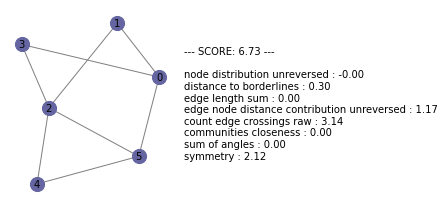

SCORE: 3.56


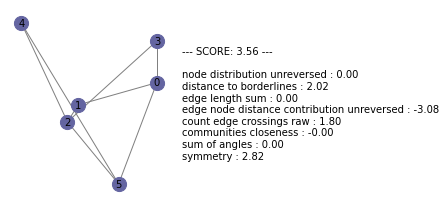

In [10]:
# nx.draw(G, pos=pos
better_score = show_graph_stats(coefficients, G, posdf, category)
worse_score = show_graph_stats(coefficients, G, posdf_worse, category)
check_if_test_passed(better_score, worse_score)

# test 2

SCORE: 9.75


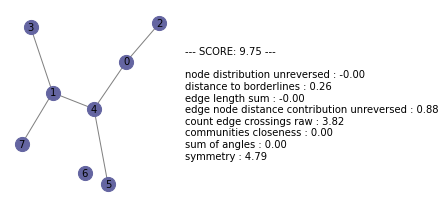

SCORE: 7.06


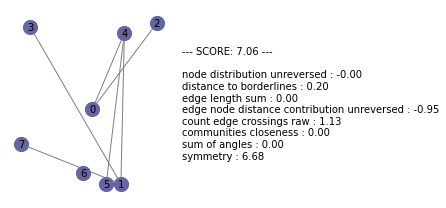

In [11]:
with open(r'tests\graph_objects\graph_ER_2_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_ER_2_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_ER_2_kamada_kawai.csv')
b=show_graph_stats(coefficients, G, posdf, category)
w=show_graph_stats(coefficients, G, posdf_worse, category)
check_if_test_passed(b,w)

# BA 

### test 3

SCORE: 8.11


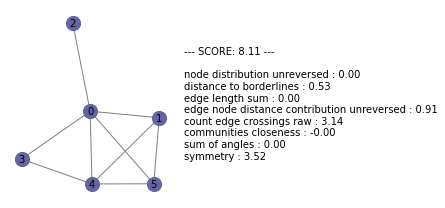

SCORE: 7.32


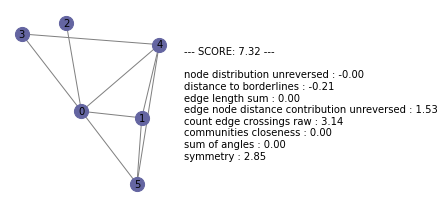

In [12]:
with open(r'tests\graph_objects\graph_BA_3_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_BA_3_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_BA_3_kamada_kawai.csv')
b=show_graph_stats(coefficients, G, posdf,  category)
w=show_graph_stats(coefficients, G, posdf_worse,  category)
check_if_test_passed(b,w)


### test 4


SCORE: 11.33


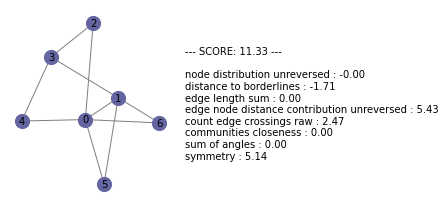

SCORE: 5.89


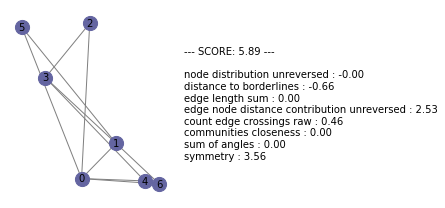

In [13]:
with open(r'tests\graph_objects\graph_BA_4_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_BA_4_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_BA_4_kamada_kawai.csv')
b=show_graph_stats(coefficients, G, posdf,  category)
w=show_graph_stats(coefficients, G, posdf_worse,  category)
check_if_test_passed(b,w)


# WS

SCORE: 10.14


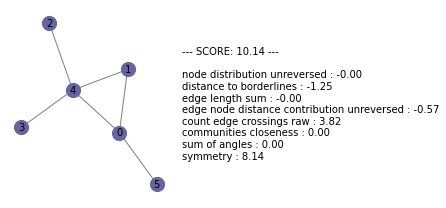

SCORE: 1.78


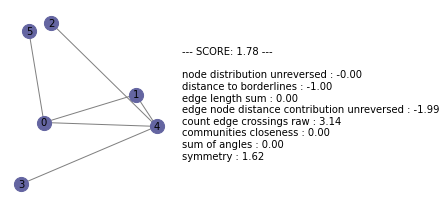

In [14]:
with open(r'tests\graph_objects\graph_WS_5_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_WS_5_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_WS_5_kamada_kawai.csv')
b=show_graph_stats(coefficients, G, posdf,  category)
w=show_graph_stats(coefficients, G, posdf_worse,  category)
check_if_test_passed(b,w)


RAW VALUES
   node_distribution_unreversed  distance_to_borderlines  edge_length_sum  \
0                     36.677424                   38.042         1.476997   

   edge_node_distance_contribution_unreversed  count_edge_crossings_raw  \
0                                   53.526458                         0   

   communities_closeness  sum_of_angles  symmetry  
0               9.069028       6.010927  0.942865  
SCALED
{'node_distribution_unreversed': 1.6224684912099314, 'distance_to_borderlines': -0.2323445668224169, 'edge_length_sum': -0.7919640628731894, 'edge_node_distance_contribution_unreversed': 1.1755871551247903, 'count_edge_crossings_raw': -0.7590237577238831, 'communities_closeness': 0.5981788486803419, 'sum_of_angles': -0.05316226777973037, 'symmetry': -0.7826052919719214}
SCORE: 14.54


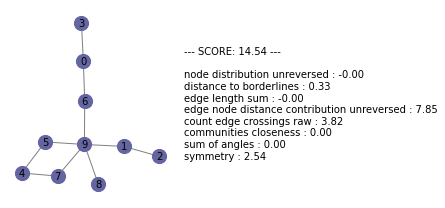

RAW VALUES
   node_distribution_unreversed  distance_to_borderlines  edge_length_sum  \
0                     40.460552                   41.057         5.939984   

   edge_node_distance_contribution_unreversed  count_edge_crossings_raw  \
0                                   53.712545                         3   

   communities_closeness  sum_of_angles  symmetry  
0               9.520705       5.560799    0.9386  
SCALED
{'node_distribution_unreversed': 1.92249243038253, 'distance_to_borderlines': -0.10064230012491104, 'edge_length_sum': 0.4767256110023479, 'edge_node_distance_contribution_unreversed': 1.1835772370337057, 'count_edge_crossings_raw': -0.35844996307169763, 'communities_closeness': 0.7053324962073408, 'sum_of_angles': -0.1240036408463644, 'symmetry': -0.9114442292198375}
SCORE: 12.81


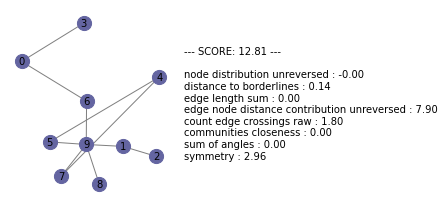

In [15]:
with open(r'tests\graph_objects\graph_WS_6_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_WS_6_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_WS_6_kamada_kawai.csv')
b=show_graph_stats(coefficients, G, posdf, category, True)
w=show_graph_stats(coefficients, G, posdf_worse, category, True)
check_if_test_passed(b,w)


# RGG

SCORE: 8.31


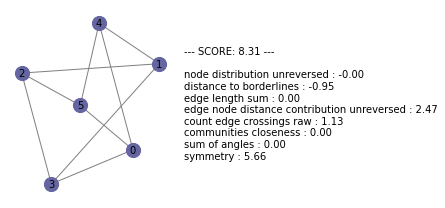

SCORE: 0.13


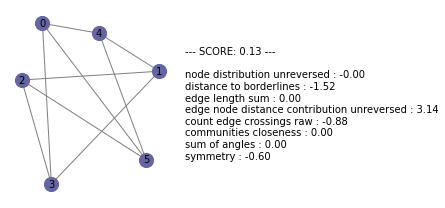

In [16]:
with open(r'tests\graph_objects\graph_RGG_7_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_RGG_7_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_RGG_7_kamada_kawai.csv')
b=show_graph_stats(coefficients, G, posdf, category)
w=show_graph_stats(coefficients, G, posdf_worse, category)
check_if_test_passed(b,w)



SCORE: 1.07


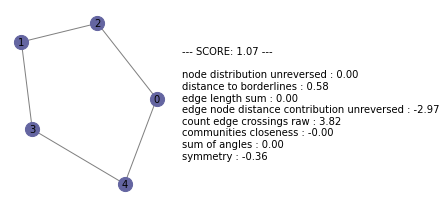

SCORE: 0.14


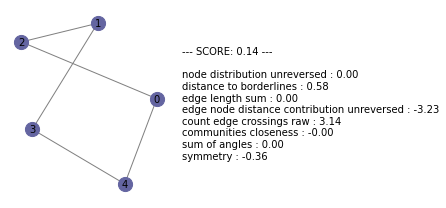

In [17]:
with open(r'tests\graph_objects\graph_RGG_8_kamada_kawai.pkl', 'rb') as f:
    G = pickle.load(f)
posdf = pd.read_csv(r'tests\pos_dfs\posdf_RGG_8_kamada_kawai.csv')
posdf_worse = pd.read_csv(r'tests\pos_dfs\posdfworse_RGG_8_kamada_kawai.csv')
b=show_graph_stats(coefficients, G, posdf,  category)
w=show_graph_stats(coefficients, G, posdf_worse,  category)
check_if_test_passed(b,w)

